<a href="https://colab.research.google.com/github/cenna-alias/test/blob/main/random_forest_regressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# STEP 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# STEP 2: Load built-in Wine dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['class'] = wine.target   # original categorical label, not used as target here
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
# STEP 3: Explore dataset
print('Shape:', df.shape)
print('\nFeatures:', wine.feature_names)
df.describe()

Shape: (178, 14)

Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [4]:
# STEP 4: Define regression target
# load_wine() only has a categorical target (3 cultivars),
# so for regression we predict a continuous feature instead: 'alcohol'
target_col = 'alcohol'

X = df.drop(['class', target_col], axis=1)
y = df[target_col]

feature_names = X.columns.tolist()

In [5]:
# STEP 5: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(142, 12) (36, 12)


In [6]:
# STEP 6: Create Random Forest Regressor
# n_estimators = number of trees
# max_depth = maximum depth of each tree
model = RandomForestRegressor(
    n_estimators=100,
    criterion='squared_error',
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)
print('Model trained successfully')

Model trained successfully


In [7]:
# STEP 7: Predictions
y_pred = model.predict(X_test)
print(y_pred[:10])

[13.35300117 13.71653918 13.12476702 13.83217108 12.92319953 13.86755258
 11.99686422 13.19689091 12.30827234 13.06177625]


In [8]:
# STEP 8: Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MSE  =', mse)
print('RMSE =', rmse)
print('MAE  =', mae)
print('R2 Score =', r2)

MSE  = 0.1479649226682382
RMSE = 0.3846620889407198
MAE  = 0.305198869909463
R2 Score = 0.7521674210218117


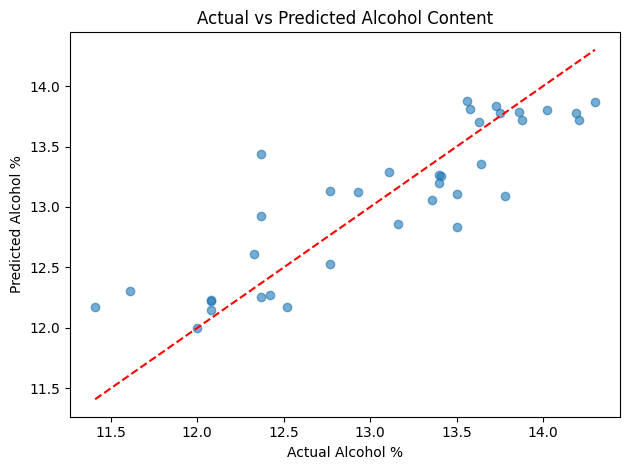

In [9]:
# STEP 9: Actual vs Predicted plot
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Alcohol %')
plt.ylabel('Predicted Alcohol %')
plt.title('Actual vs Predicted Alcohol Content')
plt.tight_layout()
plt.show()

In [10]:
# STEP 10: Feature Importance
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})
importance = importance.sort_values('Importance', ascending=False)
print(importance)

                         Feature  Importance
8                color_intensity    0.501620
11                       proline    0.156790
7                proanthocyanins    0.069765
4                  total_phenols    0.052974
1                            ash    0.046777
2              alcalinity_of_ash    0.032538
0                     malic_acid    0.029967
5                     flavanoids    0.029493
9                            hue    0.025194
6           nonflavanoid_phenols    0.021277
10  od280/od315_of_diluted_wines    0.018452
3                      magnesium    0.015152


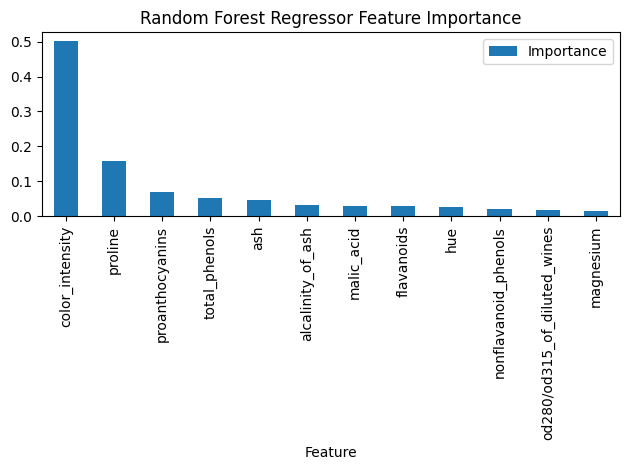

In [11]:
# STEP 11: Visualize Feature Importance
importance.plot(x='Feature', y='Importance', kind='bar')
plt.title('Random Forest Regressor Feature Importance')
plt.tight_layout()
plt.show()

In [12]:
# STEP 12: Predict alcohol content for a new wine sample
# Order must match feature_names (all columns except 'class' and 'alcohol')
print(feature_names)  # run this first to confirm order

sample = [[1.71, 2.43, 15.6, 127.0, 2.80, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065.0]]
prediction = model.predict(sample)
print('Predicted Alcohol %:', round(prediction[0], 2))

['malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Predicted Alcohol %: 14.12


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
